In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.stats import f_oneway
from scipy.stats import pearsonr, spearmanr
from scipy.stats import kendalltau
import plotly.express as px

In [3]:
mobile = pd.read_csv('/content/train.csv')
mobile.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Columns
battery_power: Total energy a battery can store in one time measured in mAh

blue: Has bluetooth or not

clock_speed: speed at which microprocessor executes instructions

dual_sim: Has dual sim support or not

fc: Front Camera mega pixels

four_g: Has 4G or not

int_memory: Internal Memory in Gigabytes

m_dep: Mobile Depth in cm

mobile_wt: Weight of mobile phone

n_cores: Number of cores of processor

pc: Primary Camera mega pixels

px_height: Pixel Resolution Height

px_width: Pixel Resolution Width

ram: Random Access Memory in Mega Bytes

sc_h: Screen Height of mobile in cm

sc_w: Screen Width of mobile in cm

talk_time:longest time that a single battery charge will last when you are

three_g:Has 3G or not

touch_screen: Has touch screen or not

wifi: Has wifi or not

price_range: This is the target variable with value of 0(low cost), 1(medium cost), 2(high cost) and 3(very high cost)

In [4]:
mobile.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [5]:
print("Dataset Shape:", mobile.shape)
print("\nColumn Names:")
print(mobile.columns.tolist())

Dataset Shape: (2000, 21)

Column Names:
['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g', 'touch_screen', 'wifi', 'price_range']


In [6]:
mobile.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [7]:
print("Duplicate rows:", mobile.duplicated().sum())

Duplicate rows: 0


In [8]:
mobile.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [9]:
# count max
print(f"Highest battery capacity: {mobile['battery_power'].max()} mAh")
# count min
print(f"Lowest battery capacity: {mobile['battery_power'].min()} mAh")
# count mean
print(f"Mean of battery capacity: {mobile['battery_power'].mean()} mAh")
# count median
print(f"Median of battery capacity: {mobile['battery_power'].median()} mAh")
# count mode
print(f"Mode of battery capacity: \n{mobile['battery_power'].mode()}")
# count standard deviation
print(f"Standard deviation of battery capacity: \n{mobile['battery_power'].std()}")
# count range
def range(series):
 return series.max() - series.min()
print(mobile[['battery_power']].agg([range]))

Highest battery capacity: 1998 mAh
Lowest battery capacity: 501 mAh
Mean of battery capacity: 1238.5185 mAh
Median of battery capacity: 1226.0 mAh
Mode of battery capacity: 
0     618
1    1589
2    1872
Name: battery_power, dtype: int64
Standard deviation of battery capacity: 
439.4182060835312
       battery_power
range           1497


In [29]:
# count max
print(f"Highest speed at which microprocessor works: {mobile['clock_speed'].max()}")
# count min
print(f"Lowest speed at which microprocessor works: {mobile['clock_speed'].min()}")
# count mean
print(f"Mean of speed at which microprocessor works: {mobile['clock_speed'].mean()}")
# count median
print(f"Median of speed at which microprocessor works: {mobile['clock_speed'].median()}")
# count mode
print(f"Mode of speed at which microprocessor works: \n{mobile['clock_speed'].mode()}")
# count standard deviation
print(f"Standard deviation of speed at which microprocessor works: \n{mobile['clock_speed'].std()}")
# count range
def range(series):
 return series.max() - series.min()
print(mobile[['clock_speed']].agg([range]))

Highest speed at which microprocessor works: 3.0
Lowest speed at which microprocessor works: 0.5
Mean of speed at which microprocessor works: 1.52225
Median of speed at which microprocessor works: 1.5
Mode of speed at which microprocessor works: 
0    0.5
Name: clock_speed, dtype: float64
Standard deviation of speed at which microprocessor works: 
0.8160042088950705
       clock_speed
range          2.5


In [37]:
# count max
print(f"Highest number of megapixels in Front Camera: {mobile['fc'].max()}")
# count min
print(f"Lowest number of megapixels in Front Camera: {mobile['fc'].min()}")
# count mean
print(f"Mean of megapixels in Front Camera: {mobile['fc'].mean()}")
# count median
print(f"Median of smegapixels in Front Camera: {mobile['fc'].median()}")
# count mode
print(f"Mode of megapixels in Front Camera: \n{mobile['fc'].mode()}")
# count standard deviation
print(f"Standard deviation of megapixels in Front Camera: \n{mobile['fc'].std()}")
# count range
def range(series):
 return series.max() - series.min()
print(mobile[['fc']].agg([range]))

Highest number of megapixels in Front Camera: 19
Lowest number of megapixels in Front Camera: 0
Mean of megapixels in Front Camera: 4.3095
Median of smegapixels in Front Camera: 3.0
Mode of megapixels in Front Camera: 
0    0
Name: fc, dtype: int64
Standard deviation of megapixels in Front Camera: 
4.341443747983884
       fc
range  19


In [11]:
import plotly.graph_objects as go

price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
bins = [500, 1000, 1500, 2000]
labels = ['500-1000', '1001-1500', '1501-2000']
mobile['battery_power_group'] = pd.cut(mobile['battery_power'], bins=bins, labels=labels, right=False)

pivot_table_battery = pd.pivot_table(mobile,
                                     values='battery_power',
                                     index='battery_power_group',
                                     columns=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                     aggfunc='count')

print(pivot_table_battery)

fig = go.Figure(data=go.Heatmap(z=pivot_table_battery, x=price_categories, y=labels))

fig.update_layout(title='Battery Power vs Price Range',
                  xaxis_title='Price Range',
                  yaxis_title='Battery Power Group', width=800, height=600)

fig.show()

/tmp/ipykernel_1327/1088525454.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table_battery = pd.pivot_table(mobile,


price_range          low cost  medium cost  high cost  very high cost
battery_power_group                                                  
500-1000                  225          169        187             114
1001-1500                 168          178        139             158
1501-2000                 107          153        174             228


In [16]:
# Assuming your dataframe is called df
df = mobile.copy()

# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Create summary table
stats_summary = pd.DataFrame(index=numeric_df.columns)

# Central tendency
stats_summary["mean"] = numeric_df.mean()
stats_summary["median"] = numeric_df.median()
stats_summary["mode"] = numeric_df.mode().iloc[0]

# Variability
stats_summary["min"] = numeric_df.min()
stats_summary["max"] = numeric_df.max()
stats_summary["range"] = stats_summary["max"] - stats_summary["min"]
stats_summary["variance"] = numeric_df.var()
stats_summary["std_dev"] = numeric_df.std()

# Distribution shape
stats_summary["skewness"] = numeric_df.apply(skew)
stats_summary["kurtosis"] = numeric_df.apply(kurtosis)

stats_summary.round(3)

,mean,median,mode,min,max,range,variance,std_dev,skewness,kurtosis
battery_power,1238.518,1226.0,618.0,501.0,1998.0,1497.0,193088.360,439.418,0.032,-1.224
blue,0.495,0.0,0.0,0.0,1.0,1.0,0.250,0.500,0.020,-2.000
clock_speed,1.522,1.5,0.5,0.5,3.0,2.5,0.666,0.816,0.178,-1.323
dual_sim,0.509,1.0,1.0,0.0,1.0,1.0,0.250,0.500,-0.038,-1.999
fc,4.310,3.0,0.0,0.0,19.0,19.0,18.848,4.341,1.019,0.273
four_g,0.522,1.0,1.0,0.0,1.0,1.0,0.250,0.500,-0.086,-1.993
int_memory,32.046,32.0,27.0,2.0,64.0,62.0,329.267,18.146,0.058,-1.216
m_dep,0.502,0.5,0.1,0.1,1.0,0.9,0.083,0.288,0.089,-1.274
mobile_wt,140.249,141.0,182.0,80.0,200.0,120.0,1253.136,35.400,0.007,-1.210
n_cores,4.520,4.0,4.0,1.0,8.0,7.0,5.234,2.288,0.004,-1.230


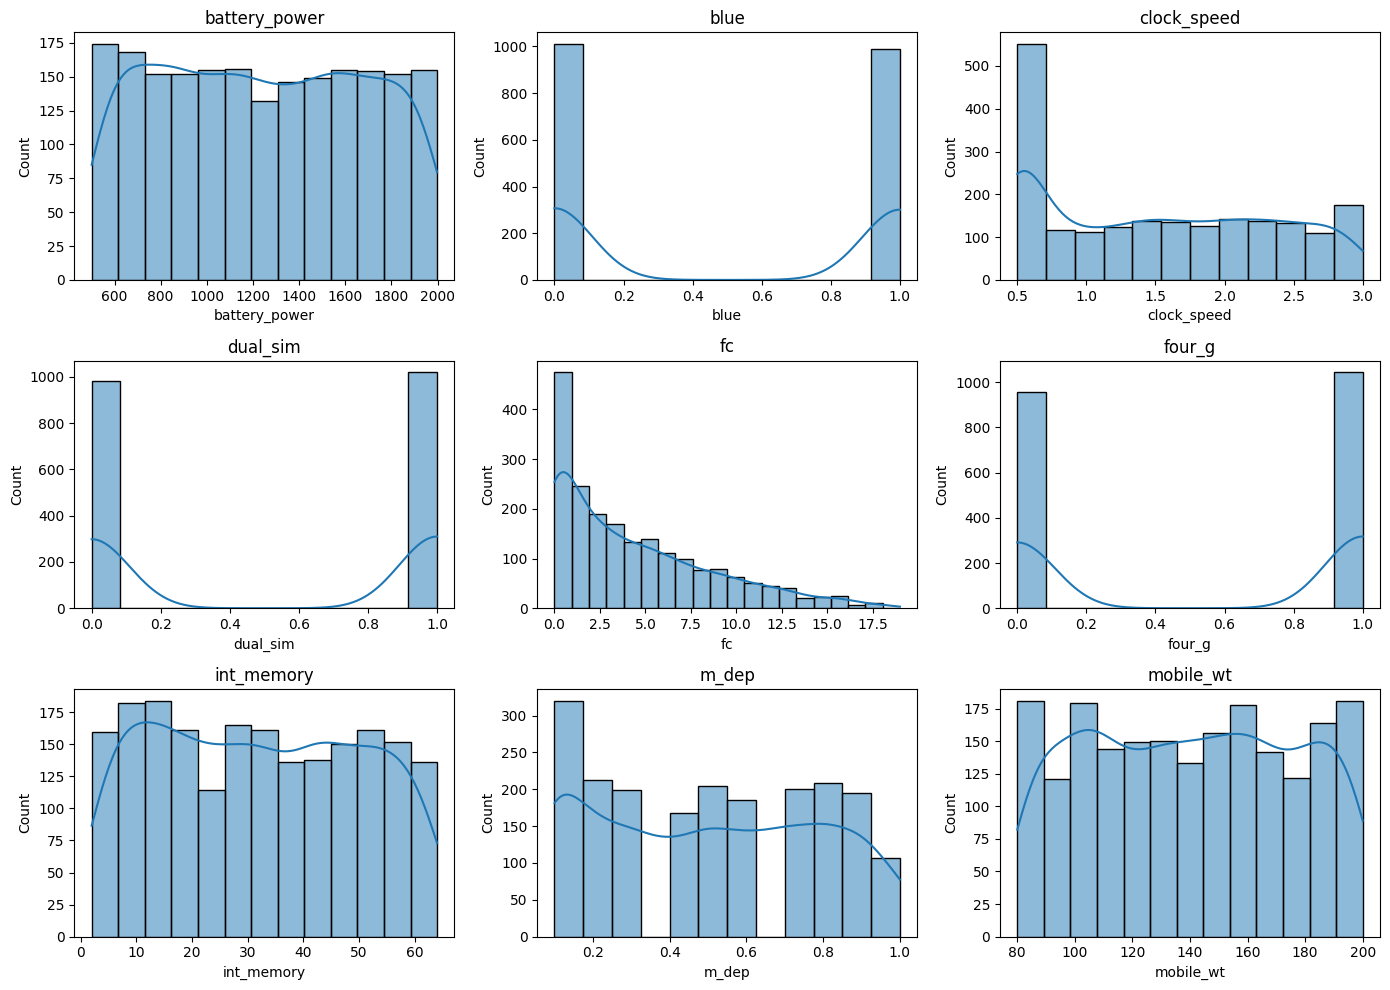

In [17]:
plt.figure(figsize=(14,10))

for i, col in enumerate(df.columns[:9], 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [20]:
results = []

features = ["ram", "battery_power", "px_width", "px_height"]

for col in features:
    groups = [group[col].values for name, group in df.groupby("price_range")]
    f_stat, p_val = f_oneway(*groups)

    results.append({
        "feature": col,
        "F_stat": f_stat,
        "p_value": p_val
    })

results_df = pd.DataFrame(results)
results_df

,feature,F_stat,p_value
0,ram,3520.110824,0.000000e+00
1,battery_power,31.598158,5.948688e-20
2,px_width,22.620882,2.116911e-14
3,px_height,19.484842,1.886085e-12


In [22]:
target = "price_range"

results = []

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target)

for col in numeric_cols:
    pearson_corr, pearson_p = pearsonr(df[col], df[target])
    spearman_corr, spearman_p = spearmanr(df[col], df[target])

    results.append({
        "feature": col,
        "pearson_corr": pearson_corr,
        "pearson_p": pearson_p,
        "spearman_corr": spearman_corr,
        "spearman_p": spearman_p
    })

corr_df = pd.DataFrame(results).sort_values(by="spearman_corr", ascending=False)
corr_df.round(3)

,feature,pearson_corr,pearson_p,spearman_corr,spearman_p
13,ram,0.917,0.000,0.917,0.000
0,battery_power,0.201,0.000,0.200,0.000
12,px_width,0.166,0.000,0.165,0.000
11,px_height,0.149,0.000,0.132,0.000
6,int_memory,0.044,0.047,0.044,0.048
10,pc,0.034,0.133,0.033,0.142
15,sc_w,0.039,0.083,0.025,0.268
4,fc,0.022,0.325,0.024,0.280
14,sc_h,0.023,0.304,0.024,0.289
17,three_g,0.024,0.291,0.024,0.291


In [24]:
kendall_results = []

for col in numeric_cols:
    tau, p_val = kendalltau(df[col], df[target])

    kendall_results.append({
        "feature": col,
        "kendall_tau": tau,
        "p_value": p_val
    })

kendall_df = pd.DataFrame(kendall_results).sort_values(by="kendall_tau", ascending=False)
kendall_df

,feature,kendall_tau,p_value
13,ram,0.791399,0.000000e+00
0,battery_power,0.148461,5.592917e-19
12,px_width,0.123132,1.566093e-13
11,px_height,0.098565,3.447817e-09
6,int_memory,0.033267,4.779564e-02
10,pc,0.025082,1.417820e-01
17,three_g,0.021554,2.911228e-01
15,sc_w,0.018893,2.735427e-01
1,blue,0.018780,3.576689e-01
4,fc,0.018601,2.877296e-01


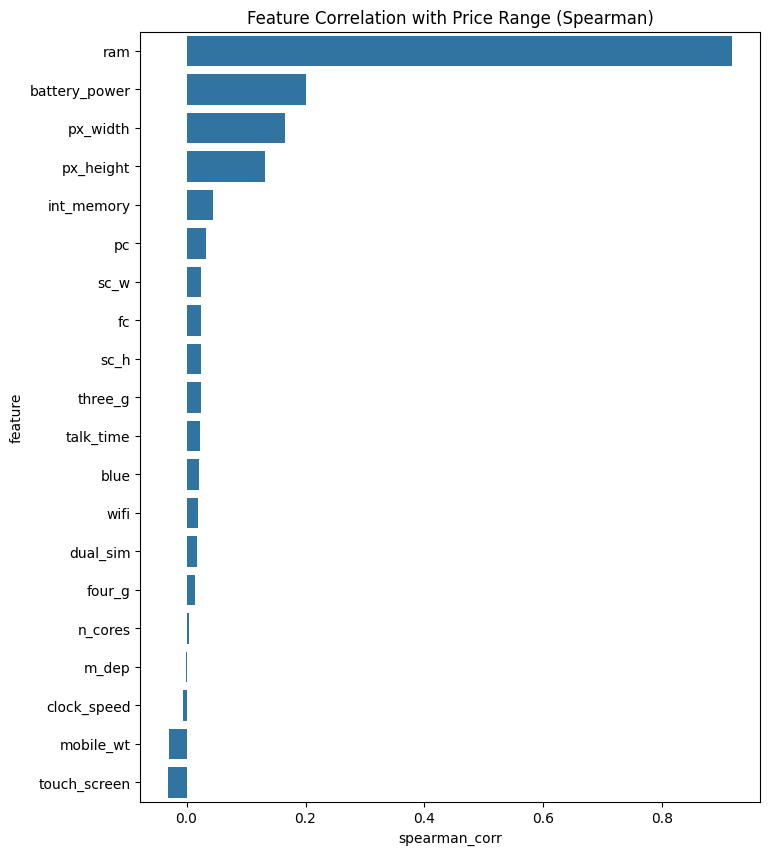

In [25]:
plt.figure(figsize=(8,10))
sns.barplot(data=corr_df, x="spearman_corr", y="feature")
plt.title("Feature Correlation with Price Range (Spearman)")
plt.show()

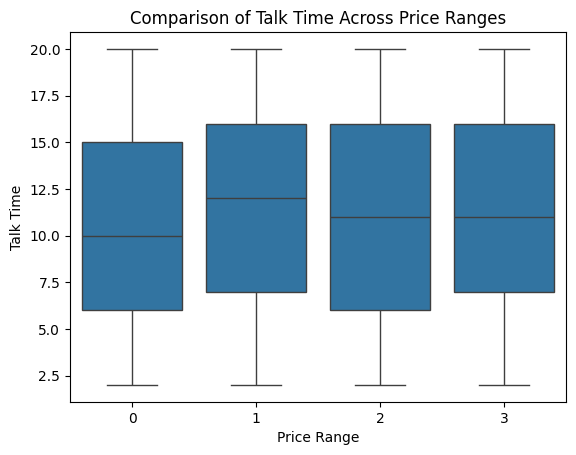

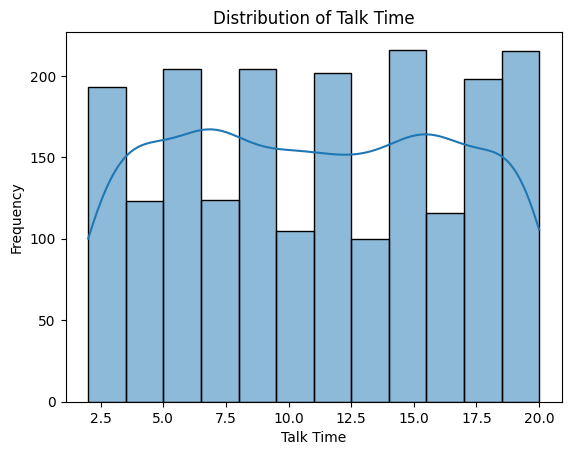

In [43]:
sns.boxplot(x='price_range', y='talk_time', data=mobile)
plt.title('Comparison of Talk Time Across Price Ranges')
plt.xlabel('Price Range')
plt.ylabel('Talk Time')
plt.show()

# Visualization of Talk Time Distribution
sns.histplot(mobile['talk_time'], kde=True)
plt.title('Distribution of Talk Time')
plt.xlabel('Talk Time')
plt.ylabel('Frequency')
plt.show()

In [26]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
# pivot table by price range count how many phones have bluetooth or not
pivot_table_blue = pd.pivot_table(mobile,
                                  values='blue', index=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                  columns=pd.cut(mobile['blue'], bins=[-1, 0, 1], labels=['No', 'Yes']),
                                  aggfunc='count')

print(pivot_table_blue)

#calculating the mode to indicate the most frequently occurring value
mode_blue = mobile['blue'].mode()

if mode_blue[0] == 0:
  print("\nMost phones without bluetooth")
else:
  print("\nMost phones with bluetooth")


fig = go.Figure(data=[
    go.Bar(name='No', x=price_categories, y=pivot_table_blue['No'], text=pivot_table_blue['No']),
    go.Bar(name='Yes', x=price_categories, y=pivot_table_blue['Yes'], text=pivot_table_blue['Yes'])])

fig.update_layout(title_text='How many phones have bluetooth or not by Price Range',xaxis_title="Price Range", yaxis_title="Count", barmode='group', width=800, height=600)
fig.show()

blue             No  Yes
price_range             
low cost        257  243
medium cost     255  245
high cost       257  243
very high cost  241  259

Most phones without bluetooth


/tmp/ipykernel_1327/4154718474.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [27]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
# pivot table by price range count how many phones have dual sim
pivot_table_dual_sim = pd.pivot_table(mobile,
                                  values='dual_sim', index=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                  columns=pd.cut(mobile['dual_sim'], bins=[-1, 0, 1], labels=['No', 'Yes']),
                                  aggfunc='count')

print(pivot_table_dual_sim)

#calculating the mode to indicate the most frequently occurring value
mode_dual_sim = mobile['dual_sim'].mode()

if mode_dual_sim[0] == 0:
  print("\nMost phones without dual sim")
else:
  print("\nMost phones with dual sim")

fig = go.Figure(data=[
    go.Bar(name='No', x=price_categories, y=pivot_table_dual_sim['No'], text=pivot_table_dual_sim['No']),
    go.Bar(name='Yes', x=price_categories, y=pivot_table_dual_sim['Yes'], text=pivot_table_dual_sim['Yes'])])

fig.update_layout(title_text='How many phones have dual sim by Price Range',xaxis_title="Price Range", yaxis_title="Count", barmode='group', width=800, height=600)
fig.show()

dual_sim         No  Yes
price_range             
low cost        250  250
medium cost     245  255
high cost       251  249
very high cost  235  265

Most phones with dual sim


/tmp/ipykernel_1327/565099532.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [28]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
# pivot table by price range count how many phones have 4G
pivot_table_four_g = pd.pivot_table(mobile,
                                  values='four_g', index=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                  columns=pd.cut(mobile['four_g'], bins=[-1, 0, 1], labels=['No', 'Yes']),
                                  aggfunc='count')

print(pivot_table_four_g)

#calculating the mode to indicate the most frequently occurring value
mode_four_g = mobile['four_g'].mode()

if mode_four_g[0] == 0:
  print("\nMost phones without 4G")
else:
  print("\nMost phones with 4G")

fig = go.Figure(data=[
    go.Bar(name='No', x=price_categories, y=pivot_table_four_g['No'], text=pivot_table_four_g['No']),
    go.Bar(name='Yes', x=price_categories, y=pivot_table_four_g['Yes'], text=pivot_table_four_g['Yes'])])

fig.update_layout(title_text='How many phones have 4G by Price Range',xaxis_title="Price Range", yaxis_title="Count", barmode='group', width=800, height=600)
fig.show()

four_g           No  Yes
price_range             
low cost        241  259
medium cost     238  262
high cost       253  247
very high cost  225  275

Most phones with 4G


/tmp/ipykernel_1327/4166696369.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [35]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
# pivot table by price range count how many phones have touch screen
pivot_table_touch_screen = pd.pivot_table(mobile,
                                  values='touch_screen', index=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                  columns=pd.cut(mobile['touch_screen'], bins=[-1, 0, 1], labels=['No', 'Yes']),
                                  aggfunc='count')

print(pivot_table_touch_screen)

#calculating the mode to indicate the most frequently occurring value
mode_touch_screen = mobile['touch_screen'].mode()

if mode_touch_screen[0] == 0:
  print("\nMost phones without touch screen")
else:
  print("\nMost phones with touch screen")

fig = go.Figure(data=[
    go.Bar(name='No', x=price_categories, y=pivot_table_touch_screen['No'], text=pivot_table_touch_screen['No']),
    go.Bar(name='Yes', x=price_categories, y=pivot_table_touch_screen['Yes'], text=pivot_table_touch_screen['Yes'])])

fig.update_layout(title_text='How many phones have touch screen by Price Range',xaxis_title="Price Range", yaxis_title="Count", barmode='group', width=800, height=600)
fig.show()

touch_screen     No  Yes
price_range             
low cost        238  262
medium cost     239  261
high cost       265  235
very high cost  252  248

Most phones with touch screen


/tmp/ipykernel_1327/3647002552.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [36]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
# pivot table by price range count how many phones have WiFi
pivot_table_wifi = pd.pivot_table(mobile,
                                  values='wifi', index=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                  columns=pd.cut(mobile['wifi'], bins=[-1, 0, 1], labels=['No', 'Yes']),
                                  aggfunc='count')

print(pivot_table_wifi)

#calculating the mode to indicate the most frequently occurring value
mode_wifi = mobile['wifi'].mode()

if mode_wifi[0] == 0:
  print("\nMost phones without WiFi")
else:
  print("\nMost phones with WiFi")

fig = go.Figure(data=[
    go.Bar(name='No', x=price_categories, y=pivot_table_wifi['No'], text=pivot_table_wifi['No']),
    go.Bar(name='Yes', x=price_categories, y=pivot_table_wifi['Yes'], text=pivot_table_wifi['Yes'])])

fig.update_layout(title_text='How many phones have WiFi by Price Range',xaxis_title="Price Range", yaxis_title="Count", barmode='group', width=800, height=600)
fig.show()

wifi             No  Yes
price_range             
low cost        252  248
medium cost     248  252
high cost       248  252
very high cost  238  262

Most phones with WiFi


/tmp/ipykernel_1327/2502978088.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [33]:
price_labels = {'0': 'low cost', '1': 'medium cost', '2': 'high cost', '3': 'very high cost'}
mobile['price_range_label'] = mobile['price_range'].astype(str).map(price_labels)

fig = px.histogram(mobile, x='clock_speed', color='price_range_label',
                   labels={'clock_speed': 'Clock Speed', 'price_range_label': 'Price Range'},
                   title='Frequency of Mobile Phones by Clock Speed and Price Range',
                   barmode='overlay')


fig.update_layout(barmode='stack', width=900, height=600)
fig.show()

In [38]:
price_labels = {'0': 'low cost', '1': 'medium cost', '2': 'high cost', '3': 'very high cost'}
mobile['price_range_label'] = mobile['price_range'].astype(str).map(price_labels)

fig = px.histogram(mobile, x='fc', color='price_range_label',
                   labels={'fc': 'Front Camera mega pixels', 'price_range_label': 'Price Range'},
                   title='Frequency of Mobile Phones by Front Camera mega pixels and Price Range',
                   barmode='overlay')


fig.update_layout(barmode='stack', width=900, height=600)
fig.show()

/tmp/ipykernel_1327/3425952273.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



<Figure size 640x480 with 0 Axes>

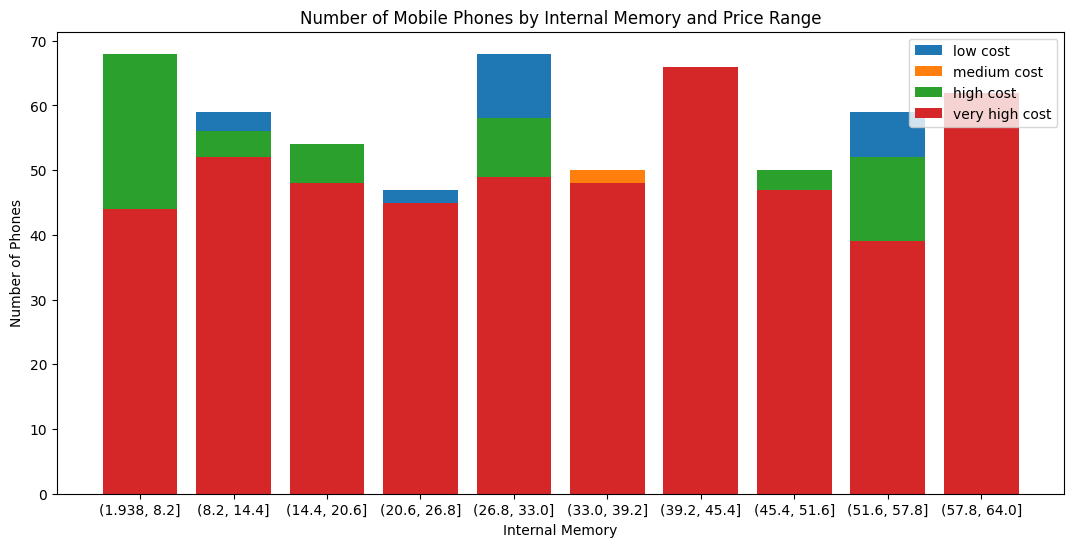

In [39]:
# pivot table by price range count by int_memory
pivot_table_int_mem = pd.pivot_table(mobile,
                                     index=pd.cut(mobile['int_memory'], bins=10),
                                     columns='price_range',
                                     aggfunc='size')
pivot_table_int_mem.columns = ['low cost', 'medium cost', 'high cost', 'very high cost']

bar_fig = plt.figure()
plt.figure(figsize=(13, 6))
for col in pivot_table_int_mem.columns:
    plt.bar(pivot_table_int_mem.index.astype(str), pivot_table_int_mem[col], label=col)

plt.title('Number of Mobile Phones by Internal Memory and Price Range')
plt.xlabel('Internal Memory')
plt.ylabel('Number of Phones')
plt.legend()

In [41]:
price_categories = ['low cost', 'medium cost', 'high cost', 'very high cost']
bins = [256, 500, 1500, 2000, 3000, 4000]
labels = ['256-500', '501-1500', '1501-2000', '2001-3000', '3001-4000']
mobile['ram_group'] = pd.cut(mobile['ram'], bins=bins, labels=labels, right=False)

pivot_table_battery = pd.pivot_table(mobile,
                                     values='ram',
                                     index='ram_group',
                                     columns=pd.cut(mobile['price_range'], bins=len(price_categories), labels=price_categories),
                                     aggfunc='count')

print(pivot_table_battery)

fig = go.Figure(data=go.Heatmap(z=pivot_table_battery, x=price_categories, y=labels))

fig.update_layout(title='RAM by Price Range',
                  xaxis_title='Price Range',
                  yaxis_title='RAM Group', width=800, height=600)

fig.show()

price_range  low cost  medium cost  high cost  very high cost
ram_group                                                    
256-500           130            2          0               0
501-1500          353          188          8               0
1501-2000          17          172         50               0
2001-3000           0          138        350              68
3001-4000           0            0         92             432


/tmp/ipykernel_1327/1290716483.py:6: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



In [42]:
# a scatter plot where the size and color of the markers are determined by the specified column RAM, INT memory and power battery by price ranges
fig = px.scatter(mobile, x='battery_power', y='ram', size='int_memory', color='price_range_label',
                 size_max=30, color_discrete_sequence=px.colors.qualitative.Dark24)


fig.update_layout(title='Scatter Plot of Battery Power vs RAM',
                  xaxis_title='Battery Power',
                  yaxis_title='RAM',
                  legend_title='Price Range', width=1200, height=800)

fig.show()

**Report**

Upon reviewing the data, we observe that the correlations between certain variables are not significant. Notably, there is a strong correlation between Random Access Memory (RAM) in Megabytes and price range, an average correlation between frontal and primary camera specifications, as well as between 3G and 4G connectivity, pixel resolution height and width, and screen height and width. However, for most other variables, the correlation is close to zero or negative.

Regarding variance, there is minimal variability or spread in the presence of Bluetooth, Clock Speed, Mobile Depth, Dual Sim, 4G, 3G, Touch Screen, and WiFi across the dataset.

Analyzing battery power by price ranges, we observe that low-cost phones tend to have lower battery capacities, while phones in the very high-cost category boast the highest capacity batteries. Interestingly, despite the prevalence of features like Bluetooth, dual SIM, 4G, 3G, touch screen, and WiFi across most phones, a significant number of them do not command a very high price. This finding is somewhat surprising, suggesting that paying a premium for such features may not always be necessary.

However, this is merely a surface-level examination. Let us delve deeper into the parameters that indicate phone productivity. We find a positive correlation between battery power and RAM, indicating that larger RAM sizes often accompany higher battery capacities.

Significant differences are evident between phones in the low-cost and very high-cost categories across parameters such as Internal Memory, Random Access Memory, Battery Power, and Primary and Front Camera specifications.

It is noteworthy that the mode of clock speed is 0.5 GHz, indicating a substantial number of phones with lower processor speeds, which may be unexpected given the industry's trend towards faster processors.

The variance of RAM is notably higher than that of other features, suggesting a wide range of RAM capacities among mobile phones in the dataset.

This analysis underscores RAM capacity, camera specifications, and connectivity features as key determinants of mobile phone prices. While battery power and talk time also influence price classification, their impact is less pronounced compared to other features. In conclusion, while it is possible to find a good phone with desirable characteristics at a lower price, those seeking top-tier phones with exceptional performance may need to invest significantly more.